# Exercise Sheet No. 2

---

> Machine Learning for Natural Sciences, Summer 2026, Prof. Pascal Friederich, pascal.friederich@kit.edu

> Instructor: Yumeng Zhang (yumeng.zhang@kit.edu)

---

**Topic**: This exercise deals with decision trees and random forests. We examine the parameters and properties of these two algorithms on a binary classification example using [`sklearn`](https://scikit-learn.org/stable/) methods.

### Please put your name and your group members here: 
You are encouraged to work in groups of a maximum of 3 people, however **each of you** has to submit a solution.

Name, student ID (uxxxx): Bahram Abdullayev, usizs, 2727213


## Preliminaries
If you are not familiar with Python, you may want to learn more about Python
and its basic syntax. Since there are a lof of free and well written tutorials
 online, we refer you to one of the following online tutorials:

* http://www.datacamp.com/community/tutorials/tutorial-jupyter-notebook
* https://www.learnpython.org/
* https://automatetheboringstuff.com/

## 1.1 Data Preprocessing and Exploration

The data we will be working with is the breast cancer dataset from the [University of Wisconsin](http://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28diagnostic%29) - a binary classification dataset for diagnosing breast cancer. \
It contains 30 features which are derived from digitized images and describe characteristics of the cell nuclei. Corresponding labels describe the stage of cancer as either \
`B`: benign, the tumor doesn’t contain cancerous cells or \
`M`: malignant, the tumor contains cancerous cells. 

### Problem Description
We want to predict whether a breast cancer tumor is benign or malignant. This is a binary classification problem since we have two output classes.\
Before we can start training our algorithms we have to get familiar with the data and prepare it:

In [79]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import requests
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

We load the dataset via the data library ``pandas``, which will return a ``DataFrame`` object. We can print the head of the table with ``.head()``:

In [80]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
data = data.frame

data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [81]:
print("number of rows:", len(data))
print("number of columns:", len(data.columns))

number of rows: 569
number of columns: 31


Now we could assign features, which is all the columns except `target` to X

In [82]:
##### DO NOT CHANGE #####
# Features and labels
X = data.drop("target", axis=1)
y = data["target"]

##### DO NOT CHANGE #####

We see that the data consists of 31 columns and 569 rows - corresponding to 569 samples.\
 `target` contains the labels.\
0 means malignant (cancerous, dangerous)\
1 means benign (non-cancerous)\
First, we want to check the distribution of classes. Use a pandas method to count the number of benign and malignant data samples. The values of your answer should be integers assigned to the variables `B` and `M`:

In [83]:
# look at distribution of classes
B = None
M = None
# YOUR CODE HERE


# YOUR CODE HERE
class_counts = y.value_counts()
B = int(class_counts[1])  
M = int(class_counts[0])  

In [84]:
##### DO NOT CHANGE #####
# ID: class_distribution - possible points: 1

# check results - 1 point

assert B is not None and M is not None, "Please assign values to B and M!"


##### DO NOT CHANGE #####

## Features
Now we have many features, however the features may be correlated with each other in reality and they are not indepedent.\
Let's visualize them and see if they are correlated with `DataFrame.corr` in pandas

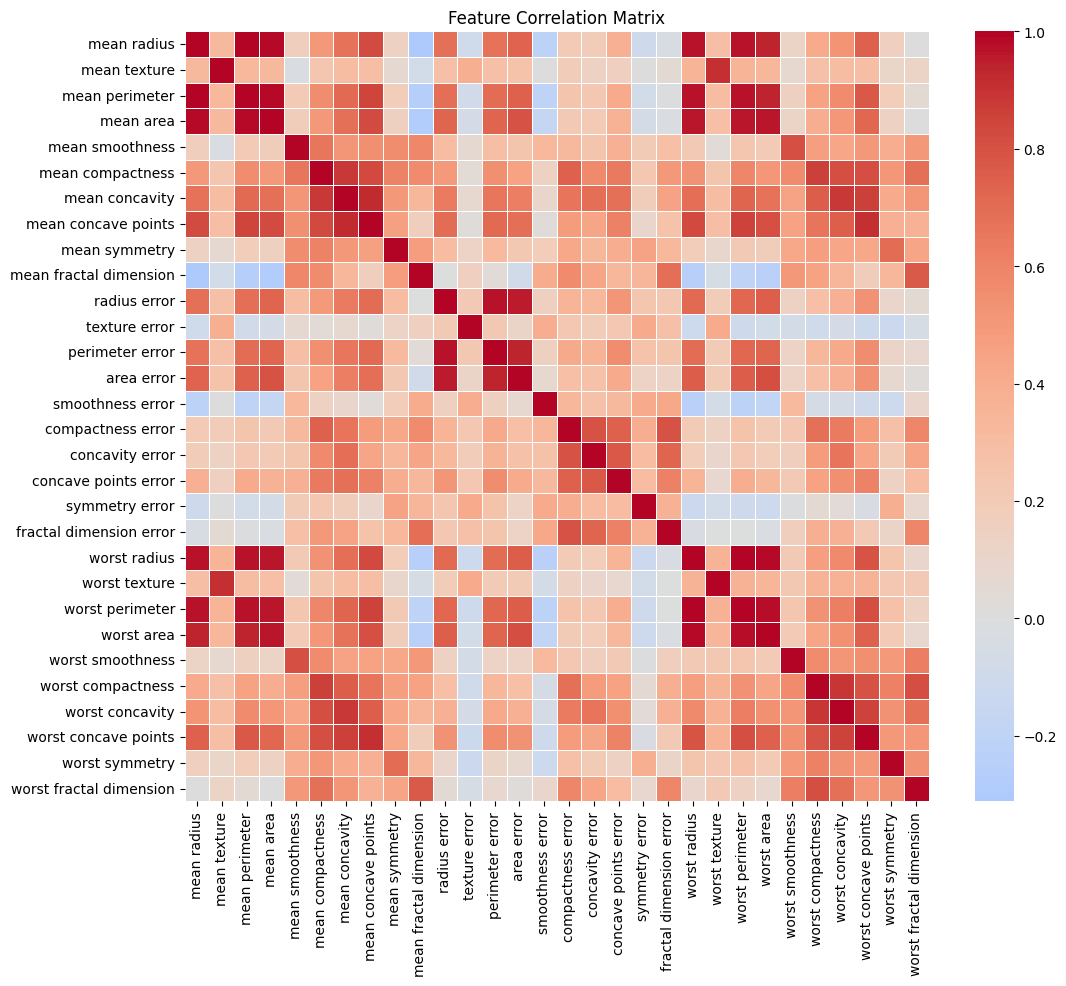

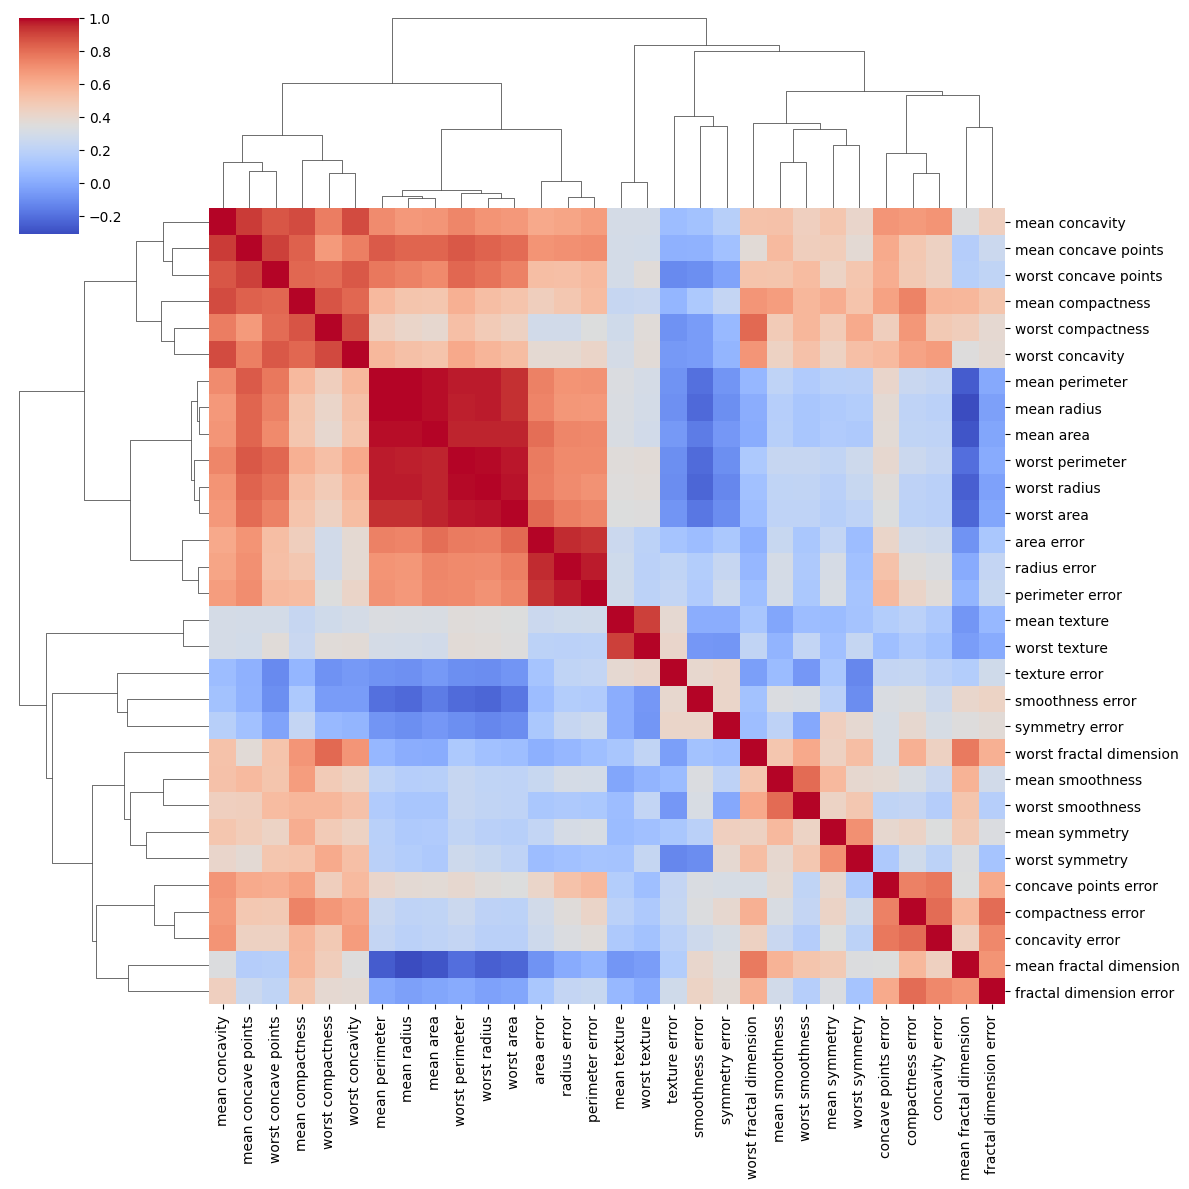

In [85]:
# 1 point
import seaborn as sns
import matplotlib.pyplot as plt
corr = []
# YOUR CODE HERE
corr = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix")
plt.show()

sns.clustermap(
    corr,
    cmap="coolwarm",
    figsize=(12, 12)
)
plt.show()

In [86]:
##### DO NOT CHANGE #####
# ID: label_encoder - possible points: 1

assert "corr" in globals(), "corr is not defined"
assert isinstance(corr, pd.DataFrame), "corr must be a pandas DataFrame"

# Structural checks
assert corr.shape == (30, 30), f"Expected shape (30, 30), got {corr.shape}"
assert np.allclose(np.diag(corr), 1.0), "Diagonal values should be 1"
assert np.allclose(corr.values, corr.values.T), "Correlation matrix should be symmetric"



##### DO NOT CHANGE #####

Obviously, some features are correlated. For example,`mean radius` and `worst radius`. We do not need all of them.\
Let's use the knowledge from last lecture about PCA, and do a feature reduction.
## Feature reduction

Before we start PCA, we need to standardize features (mandatory for PCA). Different features may be on different scales.

In [87]:
##### DO NOT CHANGE #####
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### DO NOT CHANGE #####

Now, let us apply `PCA` from last lecture

In [88]:
# 1 point
from sklearn.decomposition import PCA
X_pca = []
# YOUR CODE HERE
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [89]:
##### DO NOT CHANGE #####
# ID: cell-89a65bb172719c91 - possible points: 1

# Check existence
assert "X_pca" in globals(), "X_pca is not defined"

# Check type
assert isinstance(X_pca, np.ndarray), "X_pca must be a numpy array"

# Check shape (same samples, <= original features)
assert X_pca.shape[0] == X_scaled.shape[0], "Number of samples must match X_scaled"
assert X_pca.shape[1] <= X_scaled.shape[1], "Number of components cannot exceed original features"

# Check not all zeros
assert not np.allclose(X_pca, 0), "X_pca is all zeros"


##### DO NOT CHANGE #####

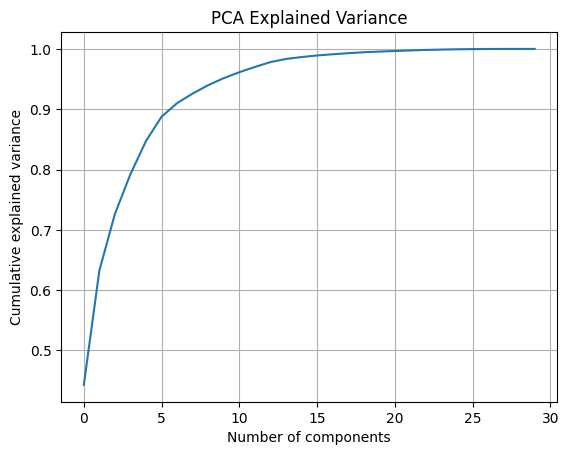

In [90]:
##### DO NOT CHANGE #####
import matplotlib.pyplot as plt
import numpy as np

explained = pca.explained_variance_ratio_

plt.plot(np.cumsum(explained))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

##### DO NOT CHANGE #####

“Cumulative explained variance” tells you how much of the original data’s variability is captured when you keep the first k principal components (PCs). \
$$
\text{Cumulative}(k) = \sum_{i=1}^{k} r_i
= \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{n} \lambda_j}
$$
As we could see, almost all could be captured with only `15` components\
Let's reduce the dimension of features by using `PCA().fit_transform` in sklearn 

In [91]:
# set n_components for PCA
pca = PCA(n_components=0.95)
X_reduced = []


# YOUR CODE HERE
X_reduced = pca.fit_transform(X_scaled)



print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (569, 30)
Reduced shape: (569, 10)


In [92]:
##### DO NOT CHANGE #####
# ID: cell-d31087498a7ecf41 - possible points: 1


assert "X_reduced" in globals(), "X_reduced is not defined"

# Check type
assert isinstance(X_reduced, np.ndarray), "X_reduced must be a numpy array"

# Same number of samples
assert X_reduced.shape[0] == X_scaled.shape[0], (
    "Number of samples must match X_scaled"
)



##### DO NOT CHANGE #####

In our last preprocessing step we need to divide the data into a training and test set. We use the training set for training and keep the test set for evaluating a trained classifier which gives us the generalization error.

We use [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html?highlight=train_test_split#sklearn.model_selection.train_test_split) to split 80% of `X` and `y` as training set and use the rest as test set, to better understand PCA and the decision tree classifier, let's try with and without dimension reduction using PCA:

In [93]:
##### DO NOT CHANGE #####
from sklearn.model_selection import train_test_split
# Not reduced 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_red, X_test_red, _, _ = train_test_split(
    X_reduced, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

##### DO NOT CHANGE #####

## 1.2 Decision Tree Classifier
We are now ready to train a decision tree classifier. \
We will use the  [`DecisionTreeClassifier()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) available in sklearn.

### Entropy and Gini Index
One parameter we have to choose is the function to measure the quality of a split i.e. the `criterion` which measures the impurity of a split.\
Possible criteria are `entropy` and `gini` which you also have seen in the lecture. Both quantify the uncertainty or disorder in a dataset's distribution of classes. A higher value implies greater disorder.\
In decision tree algorithms, the goal is therefore to reduce entropy (or the gini index) by making splits that result in more homogeneous subsets of data.

Consider a dataset with 100 samples belonging to two classes (class A and class B). Assume that each class has an equal probability of occurrence. Calculate both the entropy and the gini index of the dataset using the formulas given in the lecture.\
Assign your answers as floats to the variables below.

In [94]:
# assign values as floats - 2 points
entropy = None
gini_index = None

# YOUR CODE HERE
entropy = 1.0
gini_index = 0.5

In [95]:
##### DO NOT CHANGE #####
# ID: entropy_gini_index - possible points: 2

assert (
    entropy is not None and gini_index is not None
), "Please assign values to entropy and gini index!"


##### DO NOT CHANGE #####

We can now initialize the decision tree classifier using the gini index as splitting criterion and a fixed maximum depth of the tree. We use a specific random state to make the results reproducable :

In [96]:
##### DO NOT CHANGE #####
# Initialize DecisionTreeClassifier
tree_classifier = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

##### DO NOT CHANGE #####

Now, we can train the DecisionTreeClassifier on the training data using the fit() method:

In [97]:
##### DO NOT CHANGE #####
tree_classifier.fit(X_train, y_train)

##### DO NOT CHANGE #####

DecisionTreeClassifier(max_depth=5, random_state=42)

We can now visualize the trained tree as follows:

In [98]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(30, 20), dpi=600)
plot = plot_tree(tree_classifier, fontsize=11, class_names=["M" if c == 0 else "B" for c in tree_classifier.classes_], ax=ax, feature_names = X.columns)

Manually trace the path of a patient with the following feature values through the visualized decision tree.

worst radius = 20 \
texture error = 0.2\
Starting from the root node, follow the decision rules at each split by comparing the given feature values to the thresholds shown in the tree. Continue this process until you reach a leaf node.

Based on the class label at the final leaf node, determine whether the model would classify this patient as benign (B) or malignant (M).

In [99]:
# assign either "B" or "M" to the variable patients_class_name - 1 point

patients_class_name = None

# YOUR CODE HERE
patients_class_name = "B"

In [100]:
##### DO NOT CHANGE #####
# ID: decision_tree_predict_with_plot - possible points: 1

#  1 point
assert patients_class_name in ["B", "M"], "Please assign either 'B' or 'M' to the variable patients_class_name!"


##### DO NOT CHANGE #####

After manually predicting the class label for a single patient, let's now use the predict() method to predict the labels of all the patients in the test set to check how well the model generalizes to unseen data:

In [101]:
y_pred = None

# YOUR CODE HERE
y_pred = tree_classifier.predict(X_test)

In [102]:
##### DO NOT CHANGE #####
# ID: decision_tree_predict - possible points: 1

#  1 point


##### DO NOT CHANGE #####

### Accuracy

Since we now have the predicted labels of the test set we can use them to evaluate the accuracy of the model by comparing them to the 'true' labels.\
The accuracy is defined as:
\begin{align}
Accuracy &= \frac{Number\,of\,correct\,predictions}{Total\,number\,of\,predictions}
\end{align}

Use [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) to get the accuracy of the trained decision tree:

In [103]:
# Evaluate the accuracy of the model - 1 point

accuracy = None

# YOUR CODE HERE
accuracy = accuracy_score(y_test, y_pred)

In [104]:
##### DO NOT CHANGE #####
# ID: decision_tree_accuracy - possible points: 1

assert accuracy is not None


##### DO NOT CHANGE #####

We have tried with all the features for better visualization, let us see what would happen if we use dimension reduction.
## Reduced Feature

In [105]:
tree_classifier_red = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
tree_classifier_red.fit(X_train_red, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Now, get the `y_pred_red` and check the accuracy again:

In [106]:
y_pred_red = None
accuracy_red = None

# YOUR CODE HERE
y_pred_red = tree_classifier_red.predict(X_test_red)
accuracy_red = accuracy_score(y_test, y_pred_red)

In [107]:
##### DO NOT CHANGE #####
# ID: tree_reduced - possible points: 1

assert accuracy_red is not None


##### DO NOT CHANGE #####

## 1.3 Random Forest Classifier

A random forest classifier is an ensemble method consisting of multiple decision trees. 
By combining bagging and a random split selection, random forests generally have many advantages over single decision trees like improved generalization, robustness to noise and higher accuracy.
By averaging predictions from multiple trees, overfitting can also be reduced.
Since features are intrinsically evaluated the interpretability of single decision trees is kept.\
In this part of the exercise we fit a random forest classifier to our data and compare its perfomance to the single tree classifier.

In [108]:
##### DO NOT CHANGE #####
rf_classifier = RandomForestClassifier(n_estimators=10, max_depth=2, random_state=42)

##### DO NOT CHANGE #####

Again, fit the training data to the random forest classifier, predict the labels of the test set and evaluate the accuracy of the trained model:

In [109]:
y_pred_rf = None
accuracy_rf = None

# YOUR CODE HERE
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

In [110]:
##### DO NOT CHANGE #####
# ID: rf_implementation - possible points: 2

# check results - 2 points

##### DO NOT CHANGE #####

### Confusion Matrix 
There are many other metrics besides accuracy to evaluate the performance of a classification model.
Confusion matrices are a visual representation of how many samples were correctly and incorrectly classified.
True labels are assigned to the y-axis, predicted labels to the x-axis and each cell of the matrix contains the number of cases the specific combinatination occured.\
For example, cell (0,0) contains the number of times the model predicted the label 0 (M, malignant) correctly.

[`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

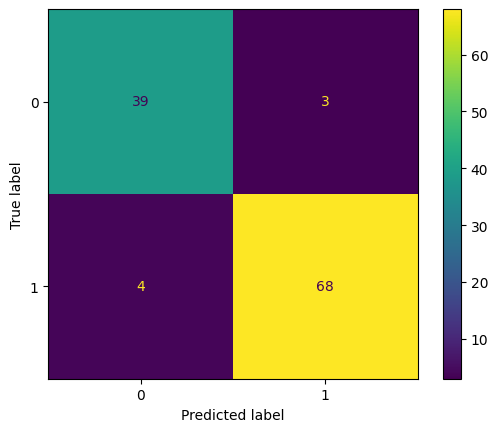

In [111]:
##### DO NOT CHANGE #####
cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

##### DO NOT CHANGE #####

From your confusion matrix, how many wrong predictions were made by the model? Assign it to `answer` as an integer:

In [112]:
answer_cm_1 = None

# YOUR CODE HERE
answer_cm_1 = 7

In [113]:
##### DO NOT CHANGE #####
# ID: rf_confusion_matrix_1 - possible points: 1

# check results - 1 points


##### DO NOT CHANGE #####

From your confusion matrix, how many samples were classified as benign by the model but are actually malignant? Assign it to `answer` as an integer:

In [114]:
answer_cm_2 = None

# YOUR CODE HERE
answer_cm_2 = 3

In [115]:
##### DO NOT CHANGE #####
# ID: rf_confusion_matrix_2 - possible points: 1

# check results - 1 points


##### DO NOT CHANGE #####

### Hyperparameters

One essential part of any machine learning application is hyperparameter optimization. Hyperparameters refer to the parameters of the algorithm itself and by tuning these parameters we can maximize the performance of the model.
In the case of a random forest classifier these include for example:\
`n_estimators` numbers of trees in the forest\
`criterion` impurity measure \
`max_depth` maximum depth of a tree

Can you improve the accuracy `accuracy_rf` of the random forest classifier by finding more suitable hyperparameters?

In [116]:
accuracy_rf_tuned = None

# YOUR CODE HERE
rf_classifier_tuned = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    random_state=42
)

rf_classifier_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_classifier_tuned.predict(X_test)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

In [117]:
##### DO NOT CHANGE #####
# ID: rf_hyperopt - possible points: 3

# check results - 3 points


##### DO NOT CHANGE #####

# Submitting your solution

As a last step, the notebook should be uploaded to Ilias such that we can auto-grade it.